In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available: []


In [2]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available: []


In [4]:

base_dir = r'D:\tealeaf project\Tea Disease Detection\teaLeafBD\teaLeafBD' 

IMG_SIZE = 224
BATCH_SIZE = 32

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% validation split 
)


class_names = [
    '1. Tea algal leaf spot', 
    '2. Brown Blight', 
    '3. Gray Blight', 
    '7. Healthy leaf', 
    '8.brown blight', 
    '9. red leaf spot',
    '4. white spot'
]
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names, 
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names, 
    subset='validation'
)

Found 2619 images belonging to 7 classes.
Found 651 images belonging to 7 classes.


In [6]:
# Load pre-trained MobileNetV2 base model
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze base model layers
base_model.trainable = False

# Add custom layers for 7 tea classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(7, activation='softmax')(x) # Classes 7 
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
!pip install Pillow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
EPOCHS = 2

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/2
82/82 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6602 - loss: 0.9061 - val_accuracy: 0.7496 - val_loss: 0.6607
Epoch 2/2
82/82 ━━━━━━━━━━━━━━━━━━━━ 59s 719ms/step - accuracy: 0.7980 - loss: 0.5312 - val_accuracy: 0.7327 - val_loss: 0.6740


In [10]:
import os

base_dir = r'D:\tealeaf project\Tea Disease Detection\teaLeafBD'

for cls in class_names:
    cls_path = os.path.join(base_dir, cls)
    if os.path.exists(cls_path):
        print(f"Folder '{cls}': {len(os.listdir(cls_path))} images found")
    else:
        print(f"❌ Folder NOT found: {cls}")

❌ Folder NOT found: 1. Tea algal leaf spot
❌ Folder NOT found: 2. Brown Blight
❌ Folder NOT found: 3. Gray Blight
❌ Folder NOT found: 7. Healthy leaf
❌ Folder NOT found: 8.brown blight
❌ Folder NOT found: 9. red leaf spot
❌ Folder NOT found: 4. white spot


In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = r'D:\tealeaf project\images (2).jpg'
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
print(f"Predicted Disease: {class_names[predicted_class_index]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
Predicted Disease: 3. Gray Blight
Confidence: 51.72%


In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = r'D:\tealeaf project\images1.jpg'
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
print(f"Predicted Disease: {class_names[predicted_class_index]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Disease: 1. Tea algal leaf spot
Confidence: 66.12%


In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = r'D:\tealeaf project\imagesw.jpg'
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
print(f"Predicted Disease: {class_names[predicted_class_index]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Disease: 3. Gray Blight
Confidence: 71.51%


In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = r'D:\tealeaf project\imagesw.jpg'
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
print(f"Predicted Disease: {class_names[predicted_class_index]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Disease: 3. Gray Blight
Confidence: 71.51%


In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = r'D:\tealeaf project\tea_algal_leaf_spot_00243.jpg'
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
print(f"Predicted Disease: {class_names[predicted_class_index]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Disease: 1. Tea algal leaf spot
Confidence: 64.80%


In [16]:
model.save('tea_disease_mobilenet.keras')

print("Model successfully saved!")

Model successfully saved!


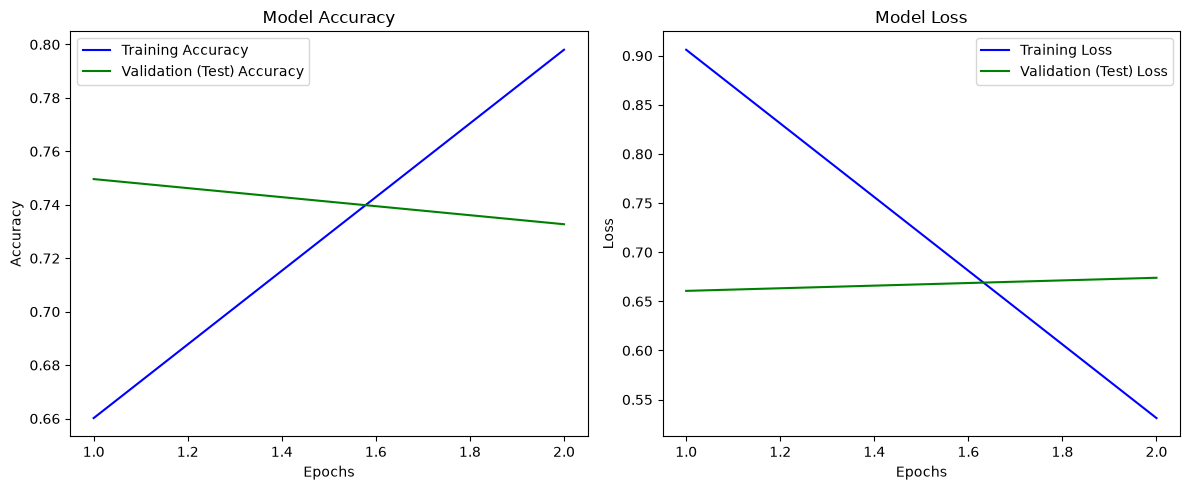

In [18]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'g', label='Validation (Test) Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'g', label='Validation (Test) Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

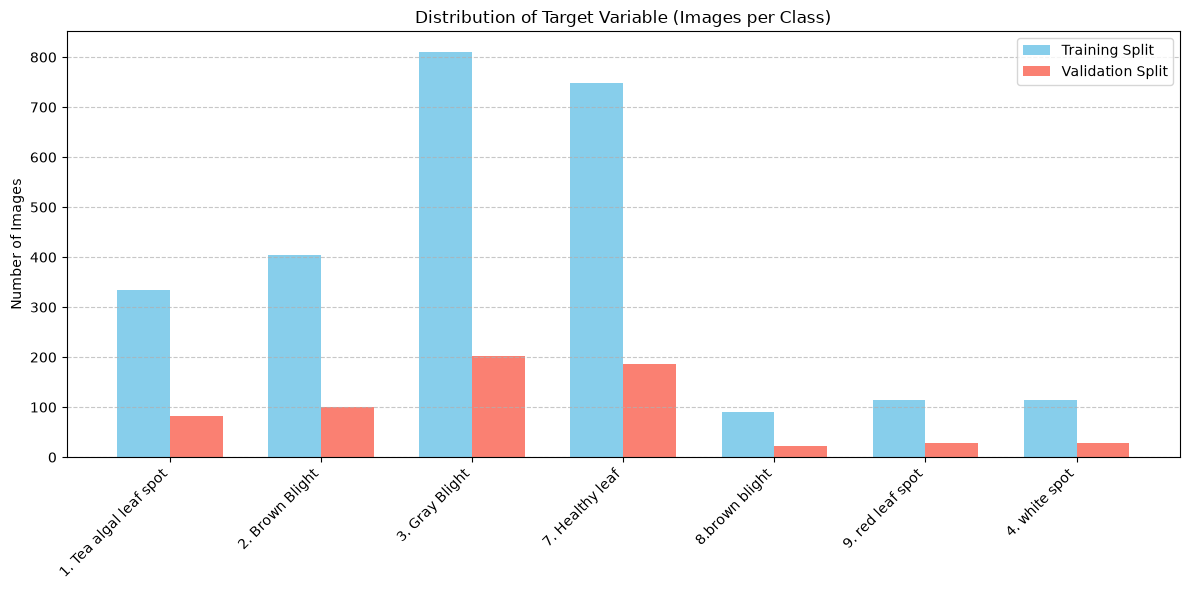

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the true class labels assigned to each image by the generators
train_classes = train_generator.classes
val_classes = val_generator.classes

# Count the occurrences of each class index
train_class_indices, train_counts = np.unique(train_classes, return_counts=True)
val_class_indices, val_counts = np.unique(val_classes, return_counts=True)

# Set up the bar chart positioning
x = np.arange(len(class_names))  # the label locations
width = 0.35                     # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Plot training and validation counts side-by-side
rects1 = ax.bar(x - width/2, train_counts, width, label='Training Split', color='skyblue')
rects2 = ax.bar(x + width/2, val_counts, width, label='Validation Split', color='salmon')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Number of Images')
ax.set_title('Distribution of Target Variable (Images per Class)')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend()

# Add a grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent cutting off the rotated labels
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Recreate validation generator without shuffling
eval_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names, 
    subset='validation',
    shuffle=False  # Crucial for matching labels!
)

# 2. Generate probability predictions
print("Generating predictions...")
Y_pred = model.predict(eval_generator)

# 3. Convert probabilities to class indices
y_pred_classes = np.argmax(Y_pred, axis=1) 

# 4. Retrieve true labels from the generator
y_true = eval_generator.classes

# 5. Compute and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: Tea Disease Detection')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [23]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------------------- ------------------- 2/4 [joblib]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-lear


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading validation images...
Found 651 images belonging to 7 classes.
Generating predictions... This may take a minute.
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 479ms/step


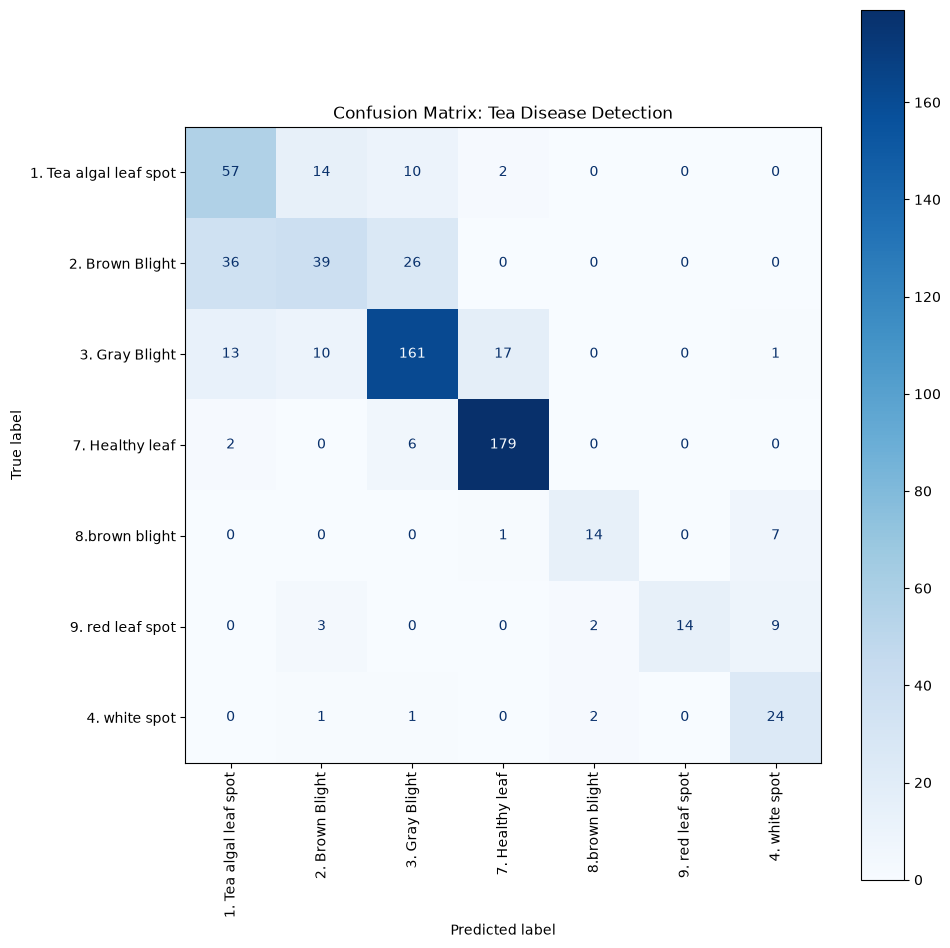

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Re-declare the EXACT correct path (nested folder)
base_dir = r'D:\tealeaf project\Tea Disease Detection\teaLeafBD\teaLeafBD'

# 2. Re-initialize the generator to guarantee the validation split exists
eval_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
)

# 3. Build the evaluation generator
print("Loading validation images...")
eval_generator = eval_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=class_names, 
    subset='validation',
    shuffle=False  # Crucial for matching labels!
)

# 4. Generate probability predictions
print("Generating predictions... This may take a minute.")
Y_pred = model.predict(eval_generator)

# 5. Convert probabilities to class indices
y_pred_classes = np.argmax(Y_pred, axis=1) 

# 6. Retrieve true labels from the generator
y_true = eval_generator.classes

# 7. Compute and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: Tea Disease Detection')
plt.tight_layout()
plt.show()